# TrAISformer Trajectory Explorer

This notebook loads the project `.pkl` trajectory files directly and supports two ways to explore them:

- A manual parameter cell that works in any notebook frontend.
- `ipywidgets` controls for interactive selection when the frontend renders Jupyter widgets correctly.

Expected record format: `{"mmsi": ..., "traj": ndarray}` where `traj` contains `[lat, lon, sog, cog, timestamp, ...]`.

## Notes

- The notebook auto-discovers `*_train.pkl`, `*_valid.pkl`, and `*_test.pkl` files under `data/ct_dma/`.
- If latitude and longitude are stored in normalized `[0, 1)` space, they are mapped back to the `ct_dma` geographic bounds used by the repo.
- In VS Code, the manual plotting cell below is the reliable fallback if widget controls do not appear.

In [27]:
from datetime import datetime, timezone
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    widgets = None
    WIDGETS_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")
print(f"ipywidgets available in this kernel: {WIDGETS_AVAILABLE}")

ipywidgets available in this kernel: True


In [28]:
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data" / "ct_dma"
LAT_BOUNDS = (55.5, 58.0)
LON_BOUNDS = (10.3, 13.0)

DATASET_FILES = {}
for path in sorted(DATA_DIR.glob("*.pkl")):
    if "coastline" in path.stem:
        continue
    split_name = path.stem.split("_")[-1]
    DATASET_FILES[split_name] = path

if not DATASET_FILES:
    raise FileNotFoundError(f"No dataset pickle files were found under {DATA_DIR}.")


def load_pickle_dataset(path: Path):
    with path.open("rb") as handle:
        data = pickle.load(handle)

    if isinstance(data, dict):
        for key in ("data", "records", "tracks"):
            if key in data and isinstance(data[key], list):
                data = data[key]
                break

    if not isinstance(data, list) or not data:
        raise TypeError(f"Expected {path.name} to contain a non-empty list of records.")

    sample = data[0]
    if not isinstance(sample, dict) or "traj" not in sample:
        raise ValueError(f"Expected records in {path.name} to contain a 'traj' entry.")

    return data


def values_look_normalized(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    return finite.size > 0 and finite.min() >= 0.0 and finite.max() <= 1.0001


def format_time_value(value, fallback_index):
    if np.isfinite(value) and 100_000_000 <= value <= 4_102_444_800:
        return datetime.fromtimestamp(float(value), tz=timezone.utc).strftime("%Y-%m-%d %H:%M")
    return f"point {fallback_index}"


def trajectory_record_to_arrays(record):
    traj = np.asarray(record["traj"], dtype=float)
    if traj.ndim != 2 or traj.shape[1] < 2:
        raise ValueError("Trajectory arrays must have shape (n_points, n_features) with at least lat/lon columns.")

    lat = traj[:, 0].copy()
    lon = traj[:, 1].copy()
    if values_look_normalized(lat) and values_look_normalized(lon):
        lat = LAT_BOUNDS[0] + lat * (LAT_BOUNDS[1] - LAT_BOUNDS[0])
        lon = LON_BOUNDS[0] + lon * (LON_BOUNDS[1] - LON_BOUNDS[0])

    sog = traj[:, 2].copy() if traj.shape[1] > 2 else np.full(len(traj), np.nan)
    cog = traj[:, 3].copy() if traj.shape[1] > 3 else np.full(len(traj), np.nan)
    if values_look_normalized(cog):
        cog = cog * 360.0

    time_values = traj[:, 4].copy() if traj.shape[1] > 4 else np.arange(len(traj), dtype=float)
    mmsi = record.get("mmsi", "unknown")
    try:
        mmsi = int(mmsi)
    except (TypeError, ValueError):
        pass

    return {
        "lat": lat,
        "lon": lon,
        "sog": sog,
        "cog": cog,
        "time": time_values,
        "mmsi": mmsi,
    }


def build_time_options(time_values):
    return [
        (f"{idx}: {format_time_value(value, idx)}", idx)
        for idx, value in enumerate(np.asarray(time_values, dtype=float))
    ]


def plot_track(split, track_index, start_idx=None, end_idx=None, arrow_step=8, show_context=True):
    if split not in datasets:
        raise KeyError(f"Unknown split: {split}. Available: {sorted(datasets)}")

    records = datasets[split]
    if not (0 <= int(track_index) < len(records)):
        raise IndexError(f"track_index must be between 0 and {len(records) - 1} for split '{split}'.")

    record = records[int(track_index)]
    track = trajectory_record_to_arrays(record)
    n_points = len(track["lat"])

    if start_idx is None:
        start_idx = 0
    if end_idx is None:
        end_idx = n_points - 1

    start_idx = int(max(0, min(start_idx, n_points - 1)))
    end_idx = int(max(0, min(end_idx, n_points - 1)))
    if start_idx > end_idx:
        start_idx, end_idx = end_idx, start_idx

    indices = np.arange(start_idx, end_idx + 1)
    lat = track["lat"]
    lon = track["lon"]
    seg_lat = lat[indices]
    seg_lon = lon[indices]

    lon_extent = np.nanmax(lon) - np.nanmin(lon)
    lat_extent = np.nanmax(lat) - np.nanmin(lat)
    arrow_scale = 0.03 * max(lon_extent, lat_extent, 1e-3)

    fig, ax = plt.subplots(figsize=(10, 8))

    if show_context:
        ax.plot(lon, lat, color="0.82", linewidth=1.5, label="Full track", zorder=1)

    scatter = ax.scatter(
        seg_lon,
        seg_lat,
        c=indices,
        cmap="viridis",
        s=34,
        zorder=3,
    )
    ax.plot(seg_lon, seg_lat, color="#1f77b4", linewidth=2.4, label="Selected window", zorder=2)
    ax.scatter(seg_lon[0], seg_lat[0], color="green", s=80, label="Start", zorder=4)
    ax.scatter(seg_lon[-1], seg_lat[-1], color="crimson", s=80, label="End", zorder=4)

    if np.isfinite(track["cog"]).any():
        arrow_step = max(1, int(arrow_step))
        for idx in range(start_idx, end_idx + 1, arrow_step):
            angle = track["cog"][idx]
            if not np.isfinite(angle):
                continue
            dx = arrow_scale * np.sin(np.deg2rad(angle))
            dy = arrow_scale * np.cos(np.deg2rad(angle))
            ax.arrow(
                lon[idx],
                lat[idx],
                dx,
                dy,
                head_width=arrow_scale * 0.35,
                head_length=arrow_scale * 0.5,
                fc="tab:red",
                ec="tab:red",
                alpha=0.45,
                length_includes_head=True,
                zorder=4,
            )

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.01)
    colorbar.set_label("Point index")

    ax.set_title(f"{split.title()} split | track {track_index}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(loc="best")

    print(
        f"MMSI: {track['mmsi']} | points: {n_points} | selected: "
        f"{format_time_value(track['time'][start_idx], start_idx)} -> {format_time_value(track['time'][end_idx], end_idx)} "
        f"({len(indices)} points)"
    )
    plt.show()
    plt.close(fig)

    return {
        "mmsi": track["mmsi"],
        "n_points": n_points,
        "start_idx": start_idx,
        "end_idx": end_idx,
    }

In [29]:
# Folium-based plotting function for vessel trajectories
import folium
from folium.plugins import PolyLineTextPath
from IPython.display import display as folium_display

def plot_track_folium(split, track_index, start_idx=None, end_idx=None, show_context=True):
    if split not in datasets:
        raise KeyError(f"Unknown split: {split}. Available: {sorted(datasets)}")
    records = datasets[split]
    if not (0 <= int(track_index) < len(records)):
        raise IndexError(f"track_index must be between 0 and {len(records) - 1} for split '{split}'.")
    record = records[int(track_index)]
    track = trajectory_record_to_arrays(record)
    n_points = len(track["lat"])
    if start_idx is None:
        start_idx = 0
    if end_idx is None:
        end_idx = n_points - 1
    start_idx = int(max(0, min(start_idx, n_points - 1)))
    end_idx = int(max(0, min(end_idx, n_points - 1)))
    if start_idx > end_idx:
        start_idx, end_idx = end_idx, start_idx
    indices = list(range(start_idx, end_idx + 1))
    lat = track["lat"]
    lon = track["lon"]
    seg_lat = lat[indices]
    seg_lon = lon[indices]
    # Center map on the mean of the selected segment
    center = [float(np.mean(seg_lat)), float(np.mean(seg_lon))]
    m = folium.Map(
        location=center,
        zoom_start=10,
        tiles=None  # We'll add a tile layer with explicit attribution
    )
    folium.TileLayer(
        tiles="https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{z}/{x}/{y}.png",
        attr="&copy; <a href='https://carto.com/attributions'>CARTO</a> | &copy; <a href='https://www.openstreetmap.org/copyright'>OpenStreetMap</a>",
        name="CartoDB Positron",
        overlay=False,
        control=True
    ).add_to(m)
    # Show full track context if requested
    if show_context:
        folium.PolyLine(list(zip(lon, lat)), color="#cccccc", weight=2, opacity=0.7, tooltip="Full track").add_to(m)
    # Selected segment
    folium.PolyLine(list(zip(seg_lon, seg_lat)), color="#3388ff", weight=4, opacity=1, tooltip="Selected window").add_to(m)
    # Start and end markers
    folium.Marker([seg_lat[0], seg_lon[0]], icon=folium.Icon(color="green"), tooltip="Start").add_to(m)
    folium.Marker([seg_lat[-1], seg_lon[-1]], icon=folium.Icon(color="red"), tooltip="End").add_to(m)
    # Optionally add arrows for COG if available
    if np.isfinite(track["cog"]).any():
        for idx in range(start_idx, end_idx + 1, max(1, (end_idx-start_idx)//10 or 1)):
            angle = track["cog"][idx]
            if not np.isfinite(angle):
                continue
            folium.RegularPolygonMarker(
                location=[lat[idx], lon[idx]],
                number_of_sides=3,
                radius=8,
                rotation=angle,
                color="crimson",
                fill_color="crimson",
                fill_opacity=0.7,
                opacity=0.7,
                tooltip=f"COG: {angle:.1f}"
            ).add_to(m)
    folium.LayerControl().add_to(m)
    folium_display(m)
    print(
        f"MMSI: {track['mmsi']} | points: {n_points} | selected: "
        f"{format_time_value(track['time'][start_idx], start_idx)} -> {format_time_value(track['time'][end_idx], end_idx)} "
        f"({len(indices)} points)"
    )

In [30]:
datasets = {split: load_pickle_dataset(path) for split, path in DATASET_FILES.items()}

for split, records in datasets.items():
    lengths = np.array([len(np.asarray(record["traj"])) for record in records], dtype=int)
    print(
        f"{split:>5}: {len(records):>6} tracks | min={lengths.min():>4} | median={np.median(lengths):>6.1f} | max={lengths.max():>4} | file={DATASET_FILES[split].name}"
    )

 test:   1593 tracks | min=  25 | median=  80.0 | max= 144 | file=ct_dma_test.pkl
train:  10605 tracks | min=  24 | median=  70.0 | max= 144 | file=ct_dma_train.pkl
valid:   1481 tracks | min=  24 | median=  75.0 | max= 144 | file=ct_dma_valid.pkl


## Manual Plot Controls

Use this cell first in VS Code if interactive widgets are missing or only show a plain `VBox(...)` text representation.

In [31]:
# Example: Plot a trajectory on a Folium map
folium_split = "train"  # or "valid", "test"
folium_track_index = 0
folium_start_idx = 0
folium_end_idx = 25
folium_show_context = True

plot_track_folium(
    split=folium_split,
    track_index=folium_track_index,
    start_idx=folium_start_idx,
    end_idx=folium_end_idx,
    show_context=folium_show_context,
)

MMSI: 205451000 | points: 66 | selected: 2019-01-01 03:35 -> 2019-01-01 07:45 (26 points)


### Folium Map Plotting (NEW)

Use the following cell to plot the selected trajectory on an interactive Folium map.

MMSI: 205451000 | points: 66 | selected: 2019-01-01 03:35 -> 2019-01-01 07:45 (26 points)


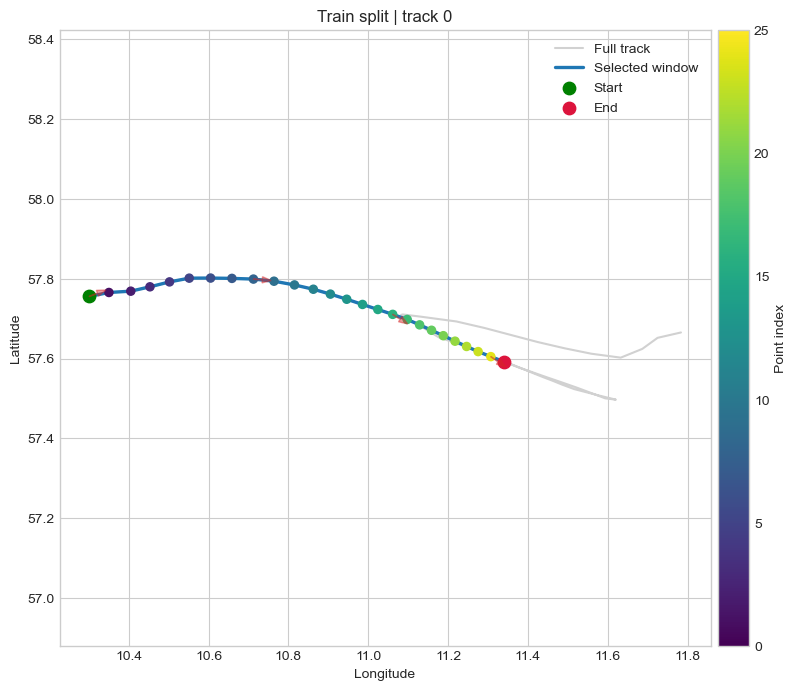

{'mmsi': 205451000, 'n_points': 66, 'start_idx': 0, 'end_idx': 25}

In [32]:
manual_split = "train"
manual_track_index = 0
manual_start_idx = 0
manual_end_idx = 25
manual_arrow_step = 8
manual_show_context = True

plot_track(
    split=manual_split,
    track_index=manual_track_index,
    start_idx=manual_start_idx,
    end_idx=manual_end_idx,
    arrow_step=manual_arrow_step,
    show_context=manual_show_context,
)

## Interactive Widget Controls

These should work in VS Code notebooks when the Jupyter frontend is rendering `ipywidgets` correctly.

In [33]:
if not WIDGETS_AVAILABLE:
    print("ipywidgets is not installed in this kernel. Use the manual plot cell above, or install ipywidgets in the selected kernel.")
else:
    split_widget = widgets.Dropdown(
        options=list(datasets.keys()),
        value=list(datasets.keys())[0],
        description="Split",
        style={"description_width": "initial"},
    )

    track_widget = widgets.BoundedIntText(
        value=0,
        min=0,
        max=len(datasets[split_widget.value]) - 1,
        description="Track index",
        style={"description_width": "initial"},
    )

    window_widget = widgets.SelectionRangeSlider(
        options=[("point 0", 0)],
        value=(0, 0),
        description="Time window",
        continuous_update=False,
        layout=widgets.Layout(width="98%"),
        style={"description_width": "initial"},
    )

    arrow_step_widget = widgets.IntSlider(
        value=8,
        min=1,
        max=25,
        step=1,
        description="Arrow step",
        continuous_update=False,
        style={"description_width": "initial"},
    )

    context_widget = widgets.Checkbox(
        value=True,
        description="Show full track context",
    )

    summary_widget = widgets.HTML()
    plot_output = widgets.Output()

    def refresh_window_widget(*_):
        records = datasets[split_widget.value]
        track_widget.max = len(records) - 1
        if track_widget.value > track_widget.max:
            track_widget.value = track_widget.max

        track = trajectory_record_to_arrays(records[track_widget.value])
        options = build_time_options(track["time"])
        window_widget.options = options
        window_widget.value = (options[0][1], options[-1][1])

    def render_plot(*_):
        if not window_widget.options:
            return

        start_idx, end_idx = window_widget.value
        if start_idx > end_idx:
            start_idx, end_idx = end_idx, start_idx

        record = datasets[split_widget.value][track_widget.value]
        track = trajectory_record_to_arrays(record)
        summary_widget.value = (
            f"<b>MMSI:</b> {track['mmsi']} &nbsp;&nbsp;"
            f"<b>Points:</b> {len(track['lat'])} &nbsp;&nbsp;"
            f"<b>Selected window:</b> {format_time_value(track['time'][start_idx], start_idx)}"
            f" to {format_time_value(track['time'][end_idx], end_idx)}"
        )

        with plot_output:
            plot_output.clear_output(wait=True)
            plot_track(
                split=split_widget.value,
                track_index=track_widget.value,
                start_idx=start_idx,
                end_idx=end_idx,
                arrow_step=arrow_step_widget.value,
                show_context=context_widget.value,
            )

    split_widget.observe(refresh_window_widget, names="value")
    track_widget.observe(refresh_window_widget, names="value")

    for control in (split_widget, track_widget, window_widget, arrow_step_widget, context_widget):
        control.observe(render_plot, names="value")

    refresh_window_widget()

    controls = widgets.VBox(
        [
            widgets.HTML("<b>If VS Code only shows a plain VBox(...) line here, use the manual plot cell above.</b>"),
            widgets.HBox([split_widget, track_widget]),
            window_widget,
            widgets.HBox([arrow_step_widget, context_widget]),
            summary_widget,
        ]
    )

    display(controls, plot_output)
    render_plot()

Output()